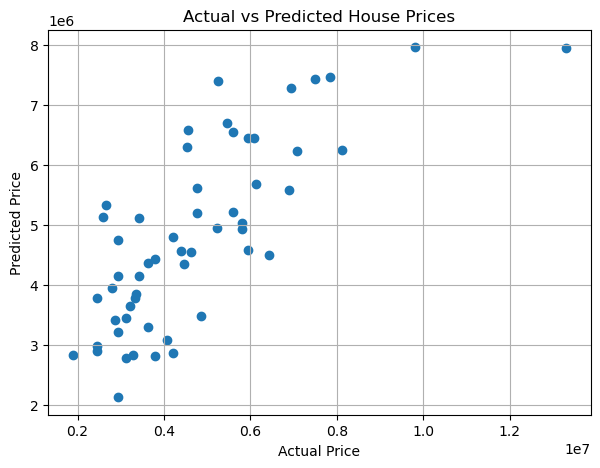

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Housing.csv")


yes_no_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning",
    "prefarea"
]

for col in yes_no_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})


df = df.drop("furnishingstatus",axis=1)


X = df.drop("price", axis=1)
y = df["price"]


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)


model = LinearRegression()
model.fit(x_train, y_train)


y_pred = model.predict(x_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


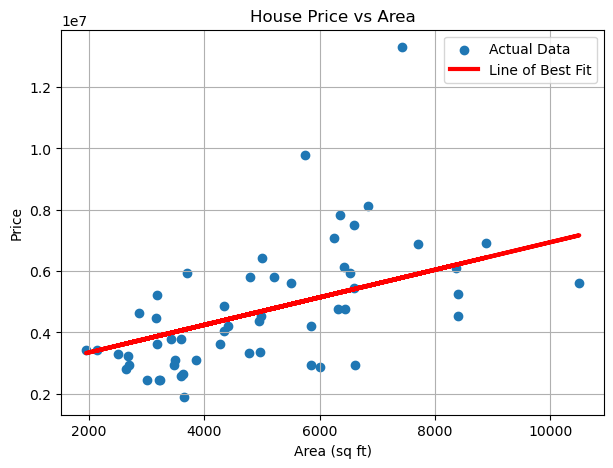

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Housing.csv")


X = df[["area"]]  
y = df["price"]


x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=1
)

model = LinearRegression()
model.fit(x_train, y_train)


# x_sorted = x_train.sort_values(by="area")
y_line = model.predict(x_test)


plt.figure(figsize=(7,5))
plt.scatter(x_test, y_test, label="Actual Data")
plt.plot(x_test, y_line,color ="red",linewidth=3, label="Line of Best Fit")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("House Price vs Area")
plt.legend()
plt.grid(True)
plt.show()


Dataset Overview:
Shape: (545, 13)

First few rows:
      price  area  bedrooms  ...  parking  prefarea furnishingstatus
0  13300000  7420         4  ...        2       yes        furnished
1  12250000  8960         4  ...        3        no        furnished
2  12250000  9960         3  ...        2       yes   semi-furnished
3  12215000  7500         4  ...        3       yes        furnished
4  11410000  7420         4  ...        2        no        furnished

[5 rows x 13 columns]

Data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad           

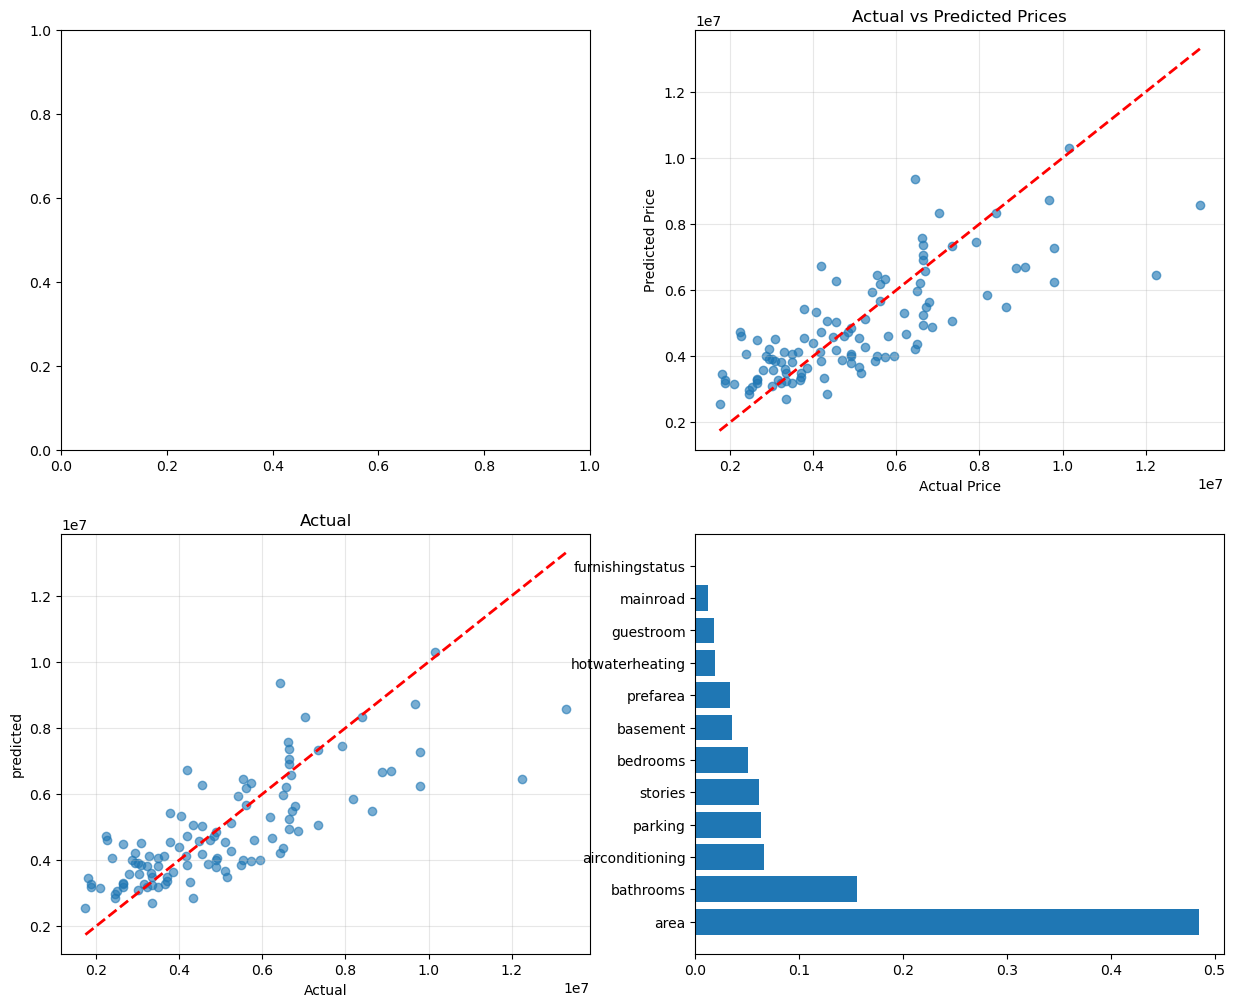

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

df = pd.read_csv("Housing.csv")

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
print(df.describe())

df_2= df.copy()

bcolumns = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]

for col in bcolumns:
    df_2[col] =df_2[col].map({"yes":1,"no":0})

furnmap = {"furnished":2,"semi-furnished":1,"unfurnished":0}
df_2["furnishingstatus"] = df_2["furnishingstatus"].map(furnmap)



X = df_2.drop("price",axis=1)
y =df_2["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("\n" + "="*50)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

X1 = df[["price"]]  
y1 = df["price"]
x_train1, x_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.1, random_state=1
)

print(f"Training set size: {x_train1.shape[0]}")
print(f"Test set size: {x_test1.shape[0]}")


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)



rf_model.fit(X_train, y_train)



y_pred_train =rf_model.predict(X_train)
y_pred_test =rf_model.predict(X_test)

print("\n" + "="*50)
print("MODEL EVALUATION:")
print("\nTraining Set Performance:")
print(f"R² Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
print(f"MAE: {mean_absolute_error(y_train, y_pred_train):,.2f}")
 
print("\nTest Set Performance:")
print(f"R² Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):,.2f}")


feature_importance =pd.DataFrame({
    "feature":X.columns,
    "importance":rf_model.feature_importances_
}).sort_values("importance",ascending=False)

print("\n" + "="*50)
print("FEATURE IMPORTANCE:")
print(feature_importance)

fig,axes = plt.subplots(2,2,figsize=(15,12))
axes[0,0]=plt.barh(feature_importance["feature"],feature_importance["importance"])
axes[0,0].set_label("Importance")
axes[0,0].set_label("Feature Importance")


axes[0,1].scatter(y_test,y_pred_test,alpha=0.64)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_xlabel("Actual Price")
axes[0,1].set_ylabel("Predicted Price")
axes[0,1].set_title("Actual vs Predicted Prices")
axes[0,1].grid(True,alpha=0.3)


axes[1,0].scatter(y_test,y_pred_test, alpha=0.6)
axes[1,0].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--",lw=2)
axes[1,0].set_xlabel("Actual")
axes[1,0].set_ylabel("predicted")
axes[1,0].set_title("Actual")
axes[1,0].grid(True,alpha=0.3)



Quadratic Regression

R²: 0.7691



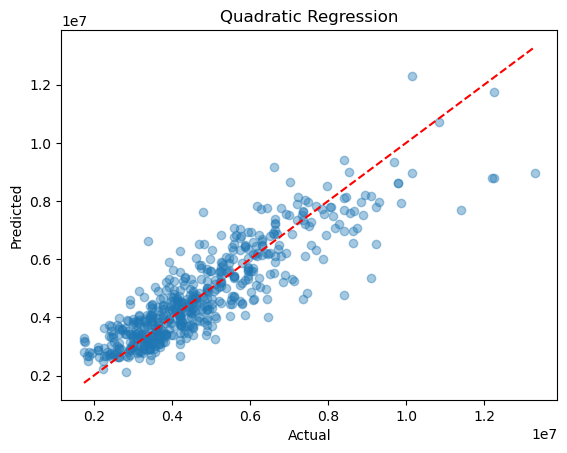

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


df = pd.read_csv('Housing.csv')

binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
})


features = ['area','bedrooms','bathrooms','stories','mainroad','guestroom',
            'basement','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']

X = df[features]
y = df['price']


poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

print("R²:", round(r2_score(y, y_pred), 4))

print()

plt.scatter(y, y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Quadratic Regression")
plt.show()